In [1]:
import pandas as pd
import numpy as np
import glob
import json
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import joblib

In [2]:
host_files = glob.glob("../Datasets/host/wls_day-*")

print("Files found:", host_files)

Files found: ['../Datasets/host\\wls_day-10', '../Datasets/host\\wls_day-16', '../Datasets/host\\wls_day-32', '../Datasets/host\\wls_day-39']


In [3]:
def process_chunk(lines):
    rows = []
    
    for line in lines:
        try:
            rows.append(json.loads(line))
        except:
            continue

    df = pd.DataFrame(rows)

    if df.empty:
        return None

    # -------- CLEANING --------
    df["EventID"] = pd.to_numeric(df["EventID"], errors="coerce")
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    def hex_to_int(x):
        try:
            return int(x, 16)
        except:
            return 0

    df["ProcessID"] = df["ProcessID"].apply(hex_to_int)
    df["ParentProcessID"] = df["ParentProcessID"].apply(hex_to_int)

    # -------- FEATURE ENGINEERING --------
    df["User_is_system"] = df["UserName"].apply(lambda x: 1 if "$" in str(x) else 0)

    df["Process_freq"] = df["ProcessName"].map(df["ProcessName"].value_counts())
    df["ParentProcess_freq"] = df["ParentProcessName"].map(df["ParentProcessName"].value_counts())

    df = df.fillna(0)

    # -------- FINAL FEATURES --------
    features = [
        "EventID",
        "Time",
        "ProcessID",
        "ParentProcessID",
        "User_is_system",
        "Process_freq",
        "ParentProcess_freq"
    ]

    return df[features]

In [6]:
TARGET_TOTAL = 5_000_000
CHUNK_SIZE = 200_000

num_files = len(host_files)
PER_FILE_TARGET = TARGET_TOTAL // num_files  # 1.25M per file

all_chunks = []

for file in host_files:
    print("\nProcessing:", file)

    collected = 0

    with open(file, 'r') as f:
        buffer = []

        for line in f:
            buffer.append(line)

            if len(buffer) >= CHUNK_SIZE:
                df_chunk = process_chunk(buffer)
                buffer = []

                if df_chunk is not None and not df_chunk.empty:

                    # sample 10%
                    df_chunk = df_chunk.sample(frac=0.1, random_state=42)

                    # 🔥 CONTROL EXACT SIZE PER FILE
                    remaining = PER_FILE_TARGET - collected

                    if remaining <= 0:
                        break

                    # trim chunk if it exceeds remaining
                    if len(df_chunk) > remaining:
                        df_chunk = df_chunk.sample(n=remaining, random_state=42)

                    all_chunks.append(df_chunk)
                    collected += len(df_chunk)

                    print(f"{file} collected:", collected)

                    if collected >= PER_FILE_TARGET:
                        break

    print(f"Finished {file} → {collected} rows")

# combine all files
data = pd.concat(all_chunks, ignore_index=True)

print("Final dataset shape:", data.shape)


Processing: ../Datasets/host\wls_day-10
../Datasets/host\wls_day-10 collected: 20000
../Datasets/host\wls_day-10 collected: 40000
../Datasets/host\wls_day-10 collected: 60000
../Datasets/host\wls_day-10 collected: 80000
../Datasets/host\wls_day-10 collected: 100000
../Datasets/host\wls_day-10 collected: 120000
../Datasets/host\wls_day-10 collected: 140000
../Datasets/host\wls_day-10 collected: 160000
../Datasets/host\wls_day-10 collected: 180000
../Datasets/host\wls_day-10 collected: 200000
../Datasets/host\wls_day-10 collected: 220000
../Datasets/host\wls_day-10 collected: 240000
../Datasets/host\wls_day-10 collected: 260000
../Datasets/host\wls_day-10 collected: 280000
../Datasets/host\wls_day-10 collected: 300000
../Datasets/host\wls_day-10 collected: 320000
../Datasets/host\wls_day-10 collected: 340000
../Datasets/host\wls_day-10 collected: 360000
../Datasets/host\wls_day-10 collected: 380000
../Datasets/host\wls_day-10 collected: 400000
../Datasets/host\wls_day-10 collected: 4200

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [8]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [9]:
preds = model.predict(X_scaled)

unique, counts = np.unique(preds, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(99571), np.int64(1): np.int64(4900429)}


In [10]:
preds = model.predict(X_scaled)

# -1 = anomaly, 1 = normal
unique, counts = np.unique(preds, return_counts=True)
result = dict(zip(unique, counts))

print("Prediction Distribution:", result)

total = len(preds)
anomaly_ratio = result.get(-1, 0) / total

print("Anomaly Ratio:", anomaly_ratio)

Prediction Distribution: {np.int64(-1): np.int64(99571), np.int64(1): np.int64(4900429)}
Anomaly Ratio: 0.0199142


In [11]:
scores = model.decision_function(X_scaled)

print("Score stats:")
print("Min:", scores.min())
print("Max:", scores.max())
print("Mean:", scores.mean())
print("Std:", scores.std())

Score stats:
Min: -0.17766936994012883
Max: 0.21427023473272777
Mean: 0.14781975095653593
Std: 0.05808051156122183


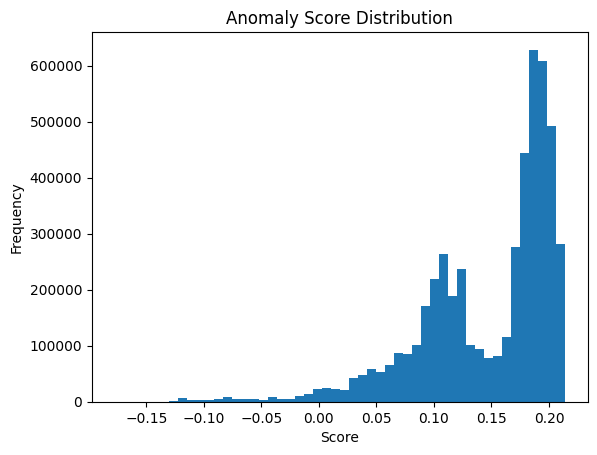

In [12]:
import matplotlib.pyplot as plt

plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [13]:
data_eval = data.copy()
data_eval["score"] = scores
data_eval["pred"] = preds

# lowest scores = most anomalous
top_anomalies = data_eval.sort_values("score").head(20)

print(top_anomalies)

         EventID     Time  ProcessID  ParentProcessID  User_is_system  \
1992861     4688  1311364     116600         112508.0               1   
1979115     4688  1311149     117676         112508.0               1   
1999031     4688  1311524     116596         112508.0               1   
1995309     4688  1311367     116172         112508.0               1   
1974461     4688  1311262     116856         112508.0               1   
1990234     4688  1311371     117184         112508.0               1   
1991003     4688  1311526     117088         112508.0               1   
2008590     4688  1311395     117020         112508.0               1   
2000819     4688  1311451     117052         112508.0               1   
1994188     4688  1311525     116128         112508.0               1   
2000465     4688  1311579     116344         112508.0               1   
2005742     4688  1311527     116344         112508.0               1   
1998094     4688  1311588     116192         112508

In [14]:
model2 = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=99,
    n_jobs=-1
)

model2.fit(X_scaled)

preds2 = model2.predict(X_scaled)

same = (preds == preds2).mean()

print("Stability (agreement):", same)

Stability (agreement): 0.991124


In [15]:
print(data.var().sort_values(ascending=False))

ParentProcessID       1.361129e+32
Time                  1.023136e+12
ProcessID             4.119238e+09
ParentProcess_freq    4.341553e+07
Process_freq          3.085476e+07
EventID               2.564614e+03
User_is_system        2.480178e-01
dtype: float64


In [16]:
import joblib

joblib.dump(model, "../Models/host_final.pkl")
joblib.dump(scaler, "../Models/host_scaler_final.pkl")

['../Models/host_scaler_final.pkl']

In [17]:
test_sample = data.sample(10000, random_state=99)

X_test = scaler.transform(test_sample)
preds = model.predict(X_test)

print(np.unique(preds, return_counts=True))

(array([-1,  1]), array([ 185, 9815]))


In [18]:
test_sample["score"] = model.decision_function(X_test)
test_sample["pred"] = preds

print(test_sample.sort_values("score").head(10))

         EventID     Time  ProcessID  ParentProcessID  User_is_system  \
1960796     4688  1310858     116032         110696.0               1   
1996070     4688  1311440      14888          15760.0               1   
2008201     4688  1311538      10360          11056.0               1   
1971598     4688  1311108        568           3344.0               1   
1977998     4688  1311292       8216           6984.0               1   
1999792     4688  1311493       1680           4840.0               1   
2000436     4688  1311588       8320           9672.0               1   
1985535     4688  1311330       9068           9672.0               1   
1998535     4688  1311404       6116           4268.0               1   
2002499     4688  1311365       5780           3108.0               1   

         Process_freq  ParentProcess_freq     score  pred  
1960796       56805.0             36500.0 -0.158014    -1  
1996070       61450.0             53806.0 -0.136886    -1  
2008201       61